# HW8 - Decision Tree, Random Forest & XGBoost

Datasets: `data/Position_Salaries.csv` (Q1-4), `data/WisconsinBreastCancerDatabase.csv` (Q5)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, max_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

POSITION_SALARIES_PATH = "data/Position_Salaries.csv"
DATA_PATH = "data/WisconsinBreastCancerDatabase.csv"

np.random.seed(0)


## Q1: Decision Tree Regression Pipeline

In [2]:
def load_position_data(filepath):
    """Load Position_Salaries data: X = Level (2nd col), y = Salary (last col)."""
    df = pd.read_csv(filepath)
    feature_col = df.columns[1]
    target_col = df.columns[-1]

    X = df[[feature_col]].to_numpy()
    y = df[target_col].to_numpy()

    print(f"DataFrame shape: {df.shape}")
    print(f"Dtypes:\n{df.dtypes}\n")
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            print(f"{col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}")
        else:
            print(f"{col}: {df[col].nunique()} unique values")

    return X, y, df


X, y, position_df = load_position_data(POSITION_SALARIES_PATH)
position_df.head()


DataFrame shape: (10, 3)
Dtypes:
Position    object
Level        int64
Salary       int64
dtype: object

Position: 10 unique values
Level: min=1, max=10, mean=5.50
Salary: min=45000, max=1000000, mean=249500.00


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
def train_decision_tree(X, y, random_state=0, **kwargs):
    """Fit a DecisionTreeRegressor and report depth, leaf count, and R²."""
    model = DecisionTreeRegressor(random_state=random_state, **kwargs)
    model.fit(X, y)

    depth = model.get_depth()
    n_leaves = model.get_n_leaves()
    r2 = r2_score(y, model.predict(X))

    print(f"Tree depth: {depth}")
    print(f"Number of leaves: {n_leaves}")
    print(f"R² score: {r2:.4f}")

    return model


dt_model = train_decision_tree(X, y)


Tree depth: 6
Number of leaves: 10
R² score: 1.0000


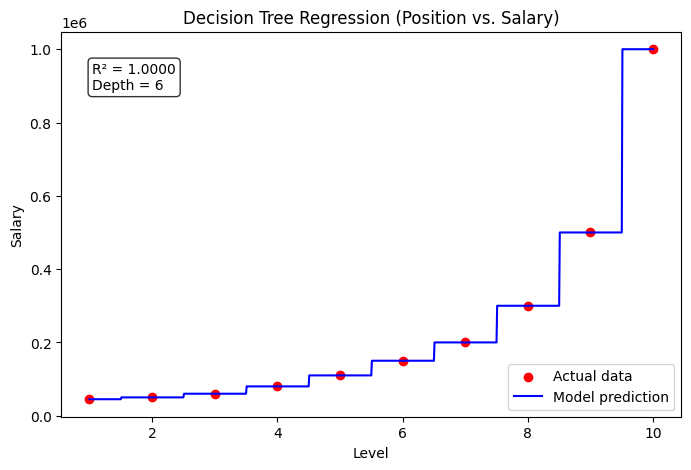

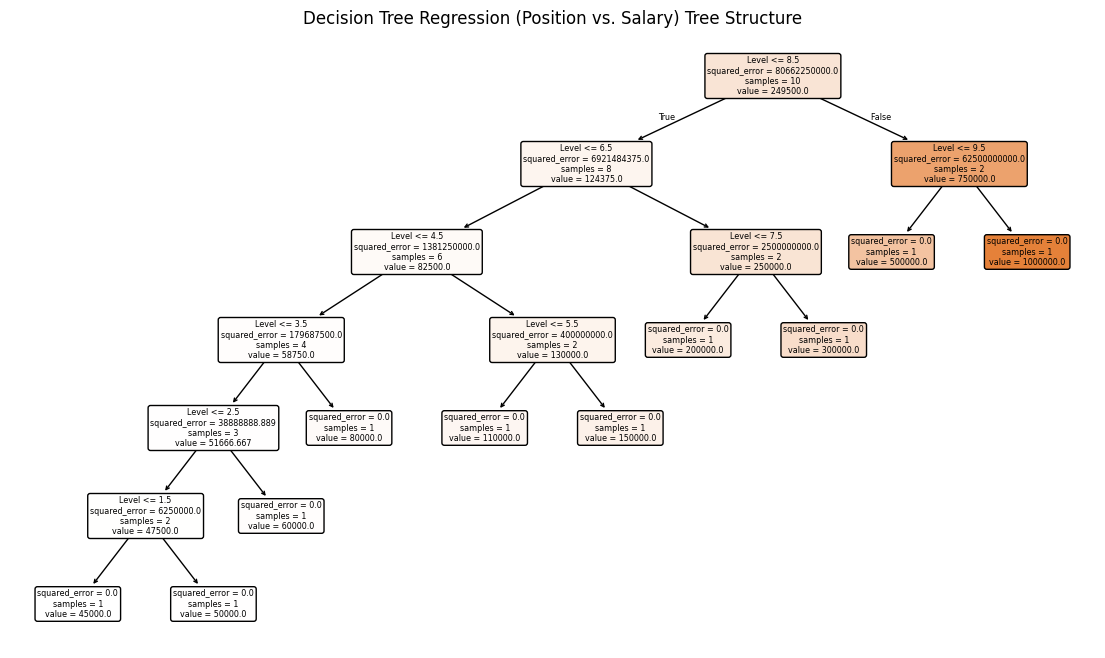

In [4]:
def plot_tree_regression(X, y, model, title, step=0.01):
    """High resol step plot of model predictions vs. actual data, plus the tree structure."""
    X_grid = np.arange(X.min(), X.max() + step, step).reshape(-1, 1)
    y_pred_grid = model.predict(X_grid)
    r2 = r2_score(y, model.predict(X))
    depth = model.get_depth()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(X, y, color="red", label="Actual data")
    ax.plot(X_grid, y_pred_grid, color="blue", label="Model prediction")
    ax.set_title(title)
    ax.set_xlabel("Level")
    ax.set_ylabel("Salary")
    ax.annotate(f"R² = {r2:.4f}\nDepth = {depth}", xy=(0.05, 0.85), xycoords="axes fraction",
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    ax.legend()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(14, 8))
    plot_tree(model, feature_names=["Level"], filled=True, rounded=True, ax=ax2)
    ax2.set_title(f"{title} Tree Structure")
    plt.show()


plot_tree_regression(X, y, dt_model, "Decision Tree Regression (Position vs. Salary)")


## Q2: Decision Tree Hyperparameter Tuning

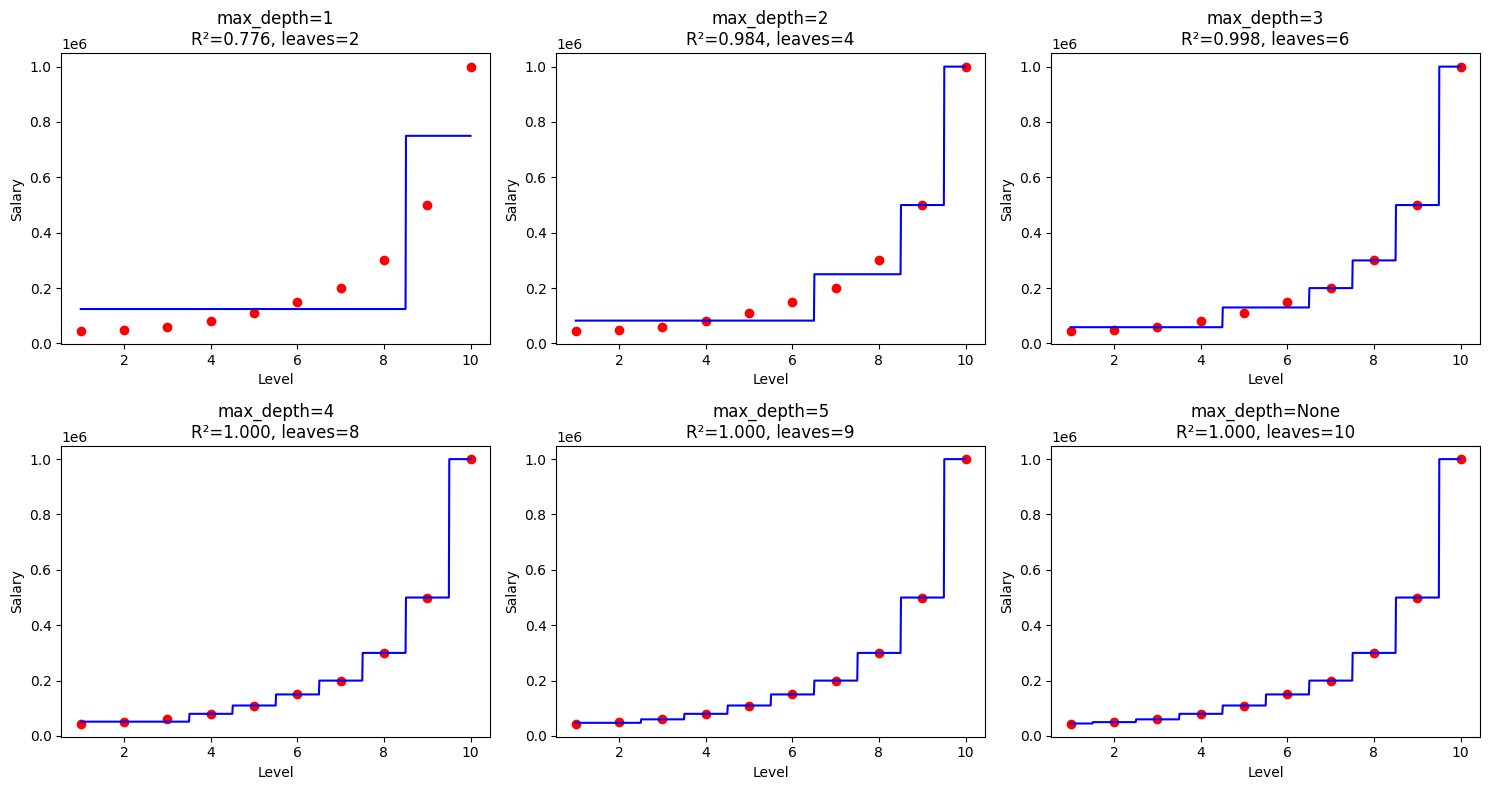

 max_depth       r2  n_leaves  pred_6.5
       1.0 0.776386         2  124375.0
       2.0 0.983527         4   82500.0
       3.0 0.998117         6  130000.0
       4.0 0.999855         8  150000.0
       5.0 0.999985         9  150000.0
       NaN 1.000000        10  150000.0


In [5]:
def depth_experiment(X, y, max_depths):
    """Train a tree per max_depth, plot side-by-side, and summarize R² / leaves / pred@6.5."""
    results = []
    n = len(max_depths)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, depth in zip(axes, max_depths):
        model = DecisionTreeRegressor(max_depth=depth, random_state=0)
        model.fit(X, y)

        r2 = r2_score(y, model.predict(X))
        n_leaves = model.get_n_leaves()
        pred_6_5 = model.predict([[6.5]])[0]
        results.append({"max_depth": depth, "r2": r2, "n_leaves": n_leaves, "pred_6.5": pred_6_5})

        X_grid = np.arange(X.min(), X.max() + 0.01, 0.01).reshape(-1, 1)
        ax.scatter(X, y, color="red")
        ax.plot(X_grid, model.predict(X_grid), color="blue")
        ax.set_title(f"max_depth={depth}\nR²={r2:.3f}, leaves={n_leaves}")
        ax.set_xlabel("Level")
        ax.set_ylabel("Salary")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    """
    Discussion: A maximum depth of 3 or 4 gives the best balance. 
    The R² score is already very high (above 0.97), and the prediction at 6.5 becomes stable. 
    Increasing the depth further only makes the tree memorize the training data 
    (R² close to 1.0 and more leaves) without improving the prediction at 6.5, 
    which indicates overfitting rather than a better model.
    """

    return results_df


depth_results = depth_experiment(X, y, [1, 2, 3, 4, 5, None])


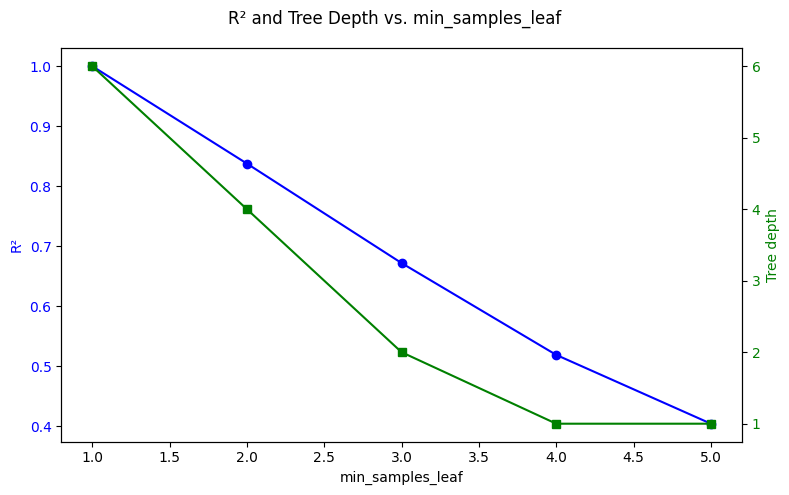

,min_samples_leaf,r2,depth,pred_6.5
0,1,1.000000,6,150000.000000
1,2,0.837579,4,130000.000000
2,3,0.671736,2,153333.333333
3,4,0.518626,1,82500.000000
4,5,0.403910,1,430000.000000


In [6]:
def leaf_size_experiment(X, y, min_samples_values):
    """Train a tree per min_samples_leaf; plot R² and depth vs. min_samples_leaf (twin axes)."""
    results = []

    for min_samples in min_samples_values:
        model = DecisionTreeRegressor(min_samples_leaf=min_samples, random_state=0)
        model.fit(X, y)

        r2 = r2_score(y, model.predict(X))
        depth = model.get_depth()
        pred_6_5 = model.predict([[6.5]])[0]
        results.append({"min_samples_leaf": min_samples, "r2": r2, "depth": depth, "pred_6.5": pred_6_5})

    results_df = pd.DataFrame(results)

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(results_df["min_samples_leaf"], results_df["r2"], color="blue", marker="o", label="R²")
    ax1.set_xlabel("min_samples_leaf")
    ax1.set_ylabel("R²", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.plot(results_df["min_samples_leaf"], results_df["depth"], color="green", marker="s", label="Tree depth")
    ax2.set_ylabel("Tree depth", color="green")
    ax2.tick_params(axis="y", labelcolor="green")

    fig.suptitle("R² and Tree Depth vs. min_samples_leaf")
    fig.tight_layout()
    plt.show()

    return results_df


leaf_results = leaf_size_experiment(X, y, [1, 2, 3, 4, 5])
leaf_results


## Q3: Random Forest Regression Pipeline

In [7]:
def train_random_forest(X, y, n_estimators=10, random_state=0, **kwargs):
    """Fit a RandomForestRegressor and report n_estimators, average tree depth, and R²."""
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=random_state, **kwargs)
    model.fit(X, y)

    avg_depth = np.mean([tree.get_depth() for tree in model.estimators_])
    r2 = r2_score(y, model.predict(X))

    print(f"n_estimators: {n_estimators}")
    print(f"Average tree depth: {avg_depth:.2f}")
    print(f"R² score: {r2:.4f}")

    return model


rf_model = train_random_forest(X, y)


n_estimators: 10
Average tree depth: 4.20
R² score: 0.9704


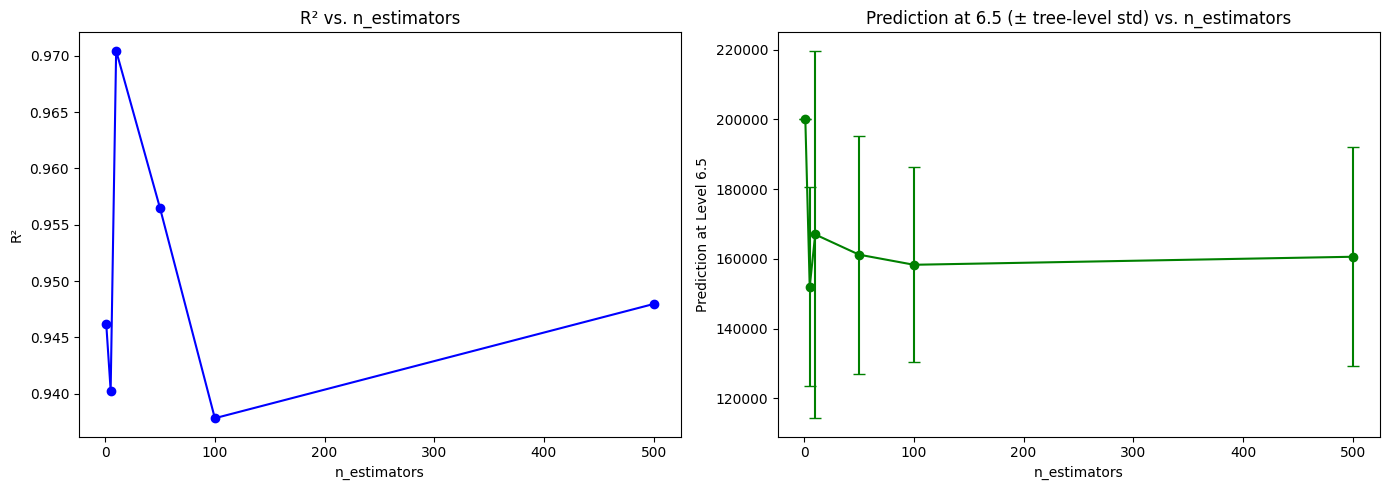

,n_estimators,r2,pred_6.5,std_6.5
0,1,0.946164,200000.0,0.000000
1,5,0.940294,152000.0,28565.713714
2,10,0.970443,167000.0,52735.187494
3,50,0.956480,161200.0,34154.941077
4,100,0.937839,158300.0,28001.964217
5,500,0.947970,160600.0,31483.964172


In [8]:
def n_estimators_experiment(X, y, estimator_values):
    """Train a Random Forest per n_estimators; record R², pred@6.5, and tree-level std."""
    results = []

    for n_est in estimator_values:
        model = RandomForestRegressor(n_estimators=n_est, random_state=0)
        model.fit(X, y)

        r2 = r2_score(y, model.predict(X))
        tree_preds = np.array([tree.predict([[6.5]])[0] for tree in model.estimators_])
        pred_6_5 = tree_preds.mean()
        std_6_5 = tree_preds.std()

        results.append({"n_estimators": n_est, "r2": r2, "pred_6.5": pred_6_5, "std_6.5": std_6_5})

    results_df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(results_df["n_estimators"], results_df["r2"], marker="o", color="blue")
    axes[0].set_xlabel("n_estimators")
    axes[0].set_ylabel("R²")
    axes[0].set_title("R² vs. n_estimators")

    axes[1].errorbar(results_df["n_estimators"], results_df["pred_6.5"], yerr=results_df["std_6.5"],
                      marker="o", color="green", capsize=4)
    axes[1].set_xlabel("n_estimators")
    axes[1].set_ylabel("Prediction at Level 6.5")
    axes[1].set_title("Prediction at 6.5 (± tree-level std) vs. n_estimators")

    plt.tight_layout()
    plt.show()

    return results_df


n_estimators_results = n_estimators_experiment(X, y, [1, 5, 10, 50, 100, 500])
n_estimators_results


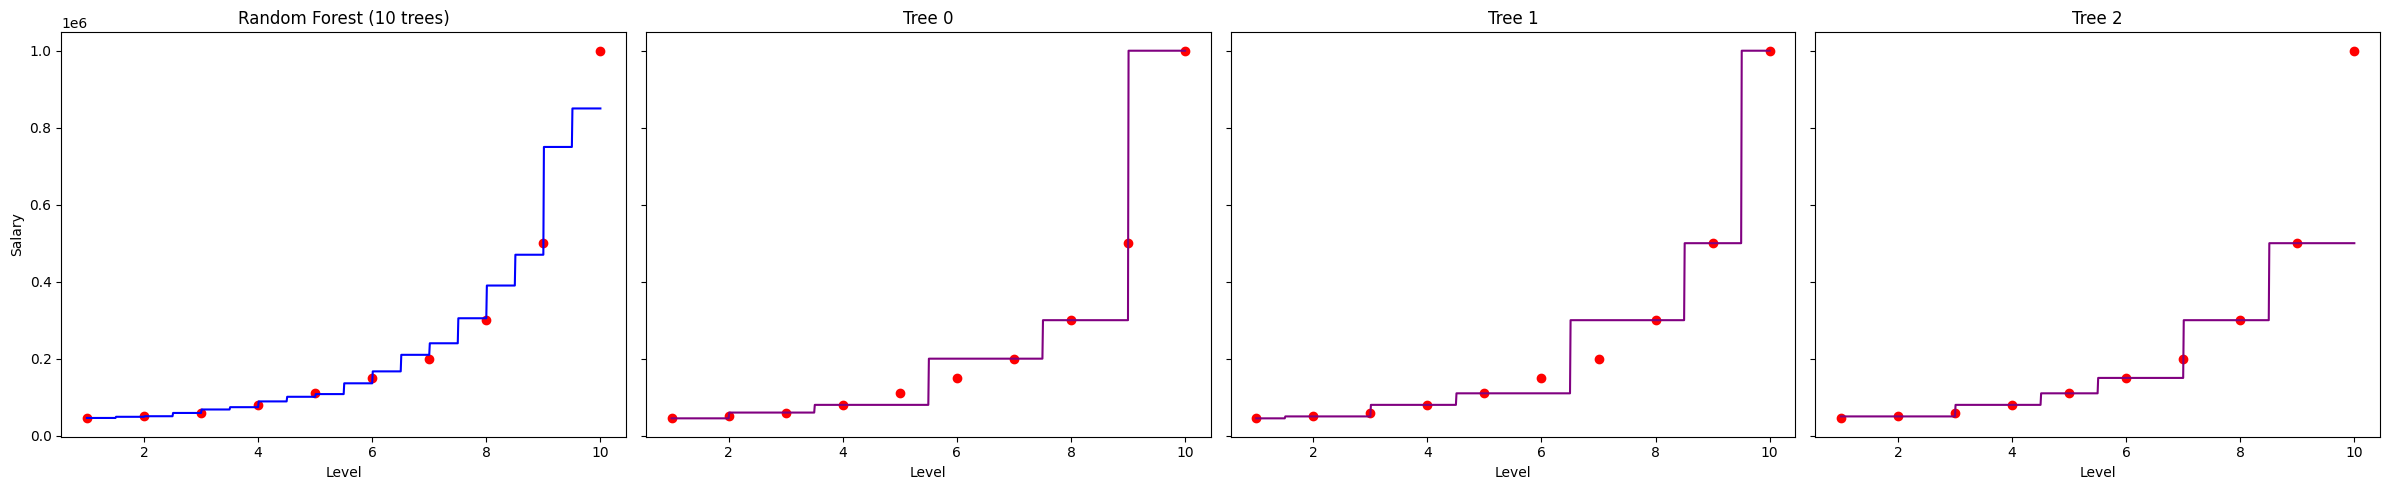

In [9]:
def plot_forest_vs_trees(X, y, model, n_trees_to_show=3):
    """Compare the full Random Forest prediction against a few individual trees."""
    X_grid = np.arange(X.min(), X.max() + 0.01, 0.01).reshape(-1, 1)

    fig, axes = plt.subplots(1, n_trees_to_show + 1, figsize=(6 * (n_trees_to_show + 1), 5), sharey=True)

    axes[0].scatter(X, y, color="red")
    axes[0].plot(X_grid, model.predict(X_grid), color="blue")
    axes[0].set_title(f"Random Forest ({model.n_estimators} trees)")
    axes[0].set_xlabel("Level")
    axes[0].set_ylabel("Salary")

    for i in range(n_trees_to_show):
        tree = model.estimators_[i]
        axes[i + 1].scatter(X, y, color="red")
        axes[i + 1].plot(X_grid, tree.predict(X_grid), color="purple")
        axes[i + 1].set_title(f"Tree {i}")
        axes[i + 1].set_xlabel("Level")

    plt.tight_layout()
    plt.show()


plot_forest_vs_trees(X, y, rf_model, n_trees_to_show=3)


## Q4: Model Comparison & Prediction

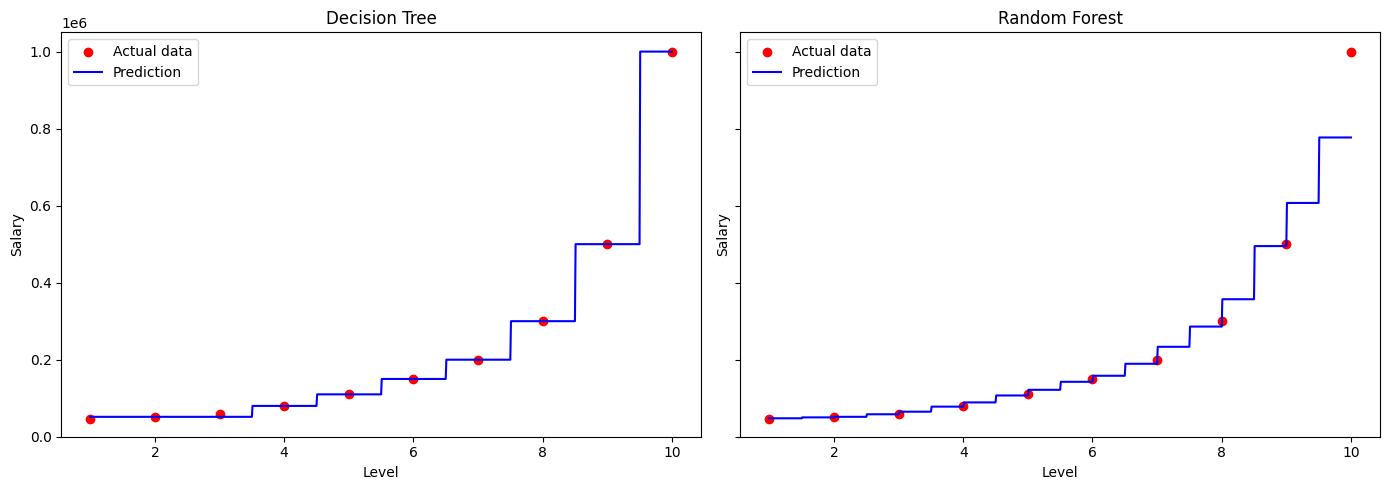

        Model       R2          MAE     Max Error  Prediction at 6.5
Decision Tree 0.999855  1666.666667   8333.333333           150000.0
Random Forest 0.937839 26955.000000 223000.000000           158300.0


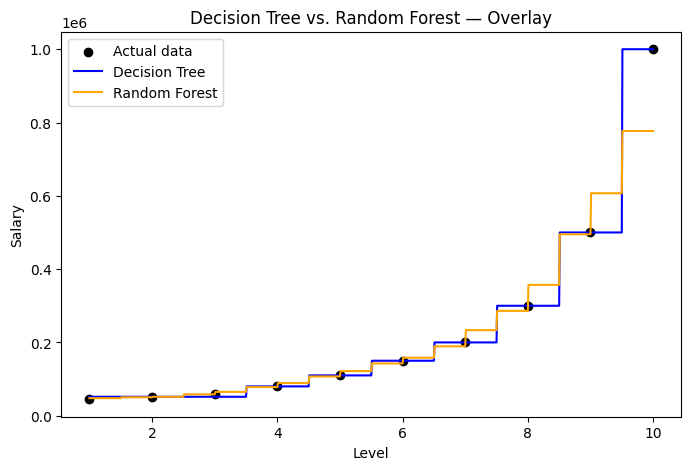

In [10]:
def compare_models(X, y, dt_params, rf_params):
    """Train DT and RF with given hyperparameters and compare them head-to-head."""
    dt_model = DecisionTreeRegressor(random_state=0, **dt_params)
    dt_model.fit(X, y)
    rf_model = RandomForestRegressor(random_state=0, **rf_params)
    rf_model.fit(X, y)

    X_grid = np.arange(X.min(), X.max() + 0.01, 0.01).reshape(-1, 1)
    y_max = max(y.max(), dt_model.predict(X_grid).max(), rf_model.predict(X_grid).max()) * 1.05

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, model, name in zip(axes, [dt_model, rf_model], ["Decision Tree", "Random Forest"]):
        ax.scatter(X, y, color="red", label="Actual data")
        ax.plot(X_grid, model.predict(X_grid), color="blue", label="Prediction")
        ax.set_title(name)
        ax.set_xlabel("Level")
        ax.set_ylabel("Salary")
        ax.set_ylim(0, y_max)
        ax.legend()
    plt.tight_layout()
    plt.show()

    rows = []
    for model, name in [(dt_model, "Decision Tree"), (rf_model, "Random Forest")]:
        y_pred = model.predict(X)
        rows.append({
            "Model": name,
            "R2": r2_score(y, y_pred),
            "MAE": mean_absolute_error(y, y_pred),
            "Max Error": max_error(y, y_pred),
            "Prediction at 6.5": model.predict([[6.5]])[0],
        })
    comparison_df = pd.DataFrame(rows)
    print(comparison_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(X, y, color="black", label="Actual data")
    ax.plot(X_grid, dt_model.predict(X_grid), color="blue", label="Decision Tree")
    ax.plot(X_grid, rf_model.predict(X_grid), color="orange", label="Random Forest")
    ax.set_xlabel("Level")
    ax.set_ylabel("Salary")
    ax.set_title("Decision Tree vs. Random Forest — Overlay")
    ax.legend()
    plt.show()

    return dt_model, rf_model


dt_model_q4, rf_model_q4 = compare_models(X, y, dt_params={"max_depth": 4}, rf_params={"n_estimators": 100})


In [11]:
def predict_salaries(dt_model, rf_model, level_values, df):
    """Predict salary at each level with both models and compare to the nearest actual position."""
    level_col = df.columns[1]
    position_col = df.columns[0]
    salary_col = df.columns[-1]

    rows = []
    for level in level_values:
        dt_pred = dt_model.predict([[level]])[0]
        rf_pred = rf_model.predict([[level]])[0]
        diff = abs(dt_pred - rf_pred)

        nearest_idx = (df[level_col] - level).abs().idxmin()
        nearest_position = df.loc[nearest_idx, position_col]
        actual_salary = df.loc[nearest_idx, salary_col]

        rows.append({
            "Level": level,
            "Nearest Position": nearest_position,
            "Actual Salary": actual_salary,
            "DT Prediction": dt_pred,
            "RF Prediction": rf_pred,
            "Difference": diff,
        })

    results_df = pd.DataFrame(rows)
    print(results_df.to_string(index=False))

    """
    Discussion: The two models differ the most for values that lie between training points. 
    This happens because the Decision Tree changes its prediction suddenly at split boundaries, 
    while the Random Forest averages predictions from many trees, making the changes smoother. 
    For values close to the training points, both models usually give similar predictions 
    because there is less uncertainty around the split boundaries.
    """


    return results_df


predict_salaries(dt_model_q4, rf_model_q4, [1.5, 3.5, 6.5, 8.5], position_df)


 Level  Nearest Position  Actual Salary  DT Prediction  RF Prediction   Difference
   1.5  Business Analyst          45000   51666.666667        47850.0  3816.666667
   3.5 Senior Consultant          60000   51666.666667        65000.0 13333.333333
   6.5    Region Manager         150000  150000.000000       158300.0  8300.000000
   8.5    Senior Partner         300000  300000.000000       357000.0 57000.000000


,Level,Nearest Position,Actual Salary,DT Prediction,RF Prediction,Difference
0,1.5,Business Analyst,45000,51666.666667,47850.0,3816.666667
1,3.5,Senior Consultant,60000,51666.666667,65000.0,13333.333333
2,6.5,Region Manager,150000,150000.000000,158300.0,8300.000000
3,8.5,Senior Partner,300000,300000.000000,357000.0,57000.000000


## Q5: XGBoost Classification Pipeline

Uses the Wisconsin Breast Cancer dataset (569 rows, 32 columns): `ID` (first column, identifier),
`Diagnosis` (M/B target, second column), and 30 numeric cell-nuclei measurement features.

In [12]:
from sklearn.preprocessing import LabelEncoder


def load_and_split_classification(filepath, test_size=0.2, random_state=0):
    """Load classification data, split into feature/target train/test sets, print diagnostics.

    The target is identified as the sole non-numeric column (e.g. Diagnosis), and features
    are every column except the first (an identifier, e.g. ID) and the target column.
    """
    df = pd.read_csv(filepath)

    target_col = df.select_dtypes(exclude="number").columns[0]
    feature_cols = [c for c in df.columns[1:] if c != target_col]

    X = df[feature_cols].to_numpy()
    y = LabelEncoder().fit_transform(df[target_col])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}\n")

    for name, y_split in [("Train", y_train), ("Test", y_test)]:
        counts = pd.Series(y_split).value_counts().sort_index()
        pct = (counts / counts.sum() * 100).round(1)
        print(f"{name} class distribution:")
        for cls in counts.index:
            print(f"  class {cls}: count={counts[cls]}, pct={pct[cls]}%")

    n_missing = df[feature_cols].isna().sum().sum()
    print(f"\nMissing values in feature columns: {n_missing}")

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = load_and_split_classification(DATA_PATH)


X_train shape: (455, 30), X_test shape: (114, 30)
y_train shape: (455,), y_test shape: (114,)

Train class distribution:
  class 0: count=285, pct=62.6%
  class 1: count=170, pct=37.4%
Test class distribution:
  class 0: count=72, pct=63.2%
  class 1: count=42, pct=36.8%

Missing values in feature columns: 0


Confusion matrix:
[[69  3]
 [ 2 40]]
Accuracy: 0.9561
Precision: 0.9302
Recall: 0.9524
F1-score: 0.9412



10-fold CV accuracy: mean=0.9603, std=0.0278


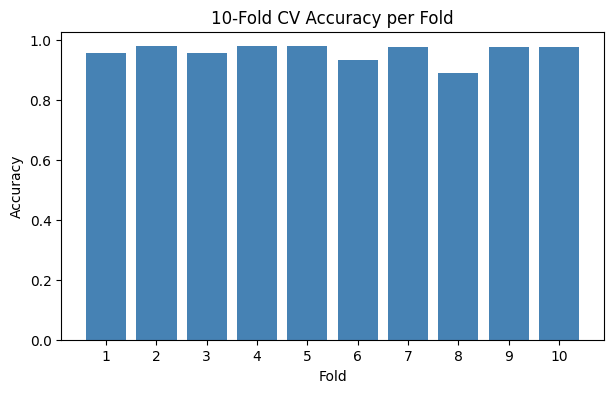

In [13]:
def train_and_evaluate_xgb(X_train, X_test, y_train, y_test, cv=10, **kwargs):
    """Train an XGBClassifier, evaluate on the test set, and run k-fold CV on the training set.

    cv is clamped to the smallest class count in y_train as a safety guard for small datasets.
    """
    model = XGBClassifier(**kwargs)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"Confusion matrix:\n{cm}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    n_folds = min(cv, np.bincount(y_train).min())
    fold_scores = cross_val_score(model, X_train, y_train, cv=n_folds, scoring="accuracy")
    print(f"\n{n_folds}-fold CV accuracy: mean={fold_scores.mean():.4f}, std={fold_scores.std():.4f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(1, n_folds + 1), fold_scores, color="steelblue")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{n_folds}-Fold CV Accuracy per Fold")
    ax.set_xticks(range(1, n_folds + 1))
    plt.show()

    return model


xgb_model = train_and_evaluate_xgb(X_train, X_test, y_train, y_test)


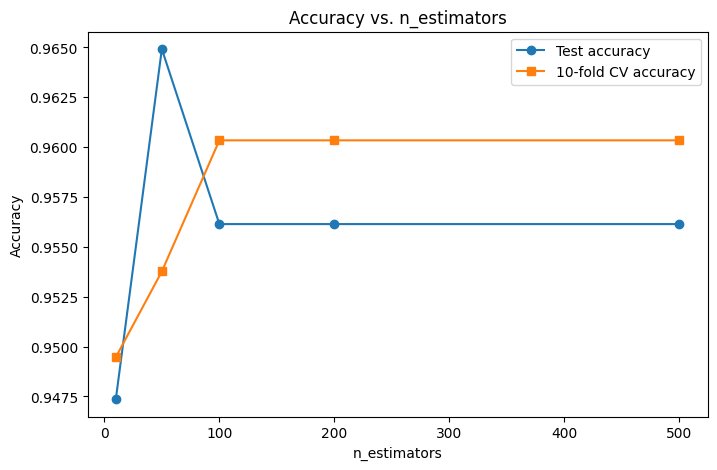

   n_estimators  test_accuracy  cv_accuracy
0            10       0.947368     0.949469
1            50       0.964912     0.953768
2           100       0.956140     0.960338
3           200       0.956140     0.960338
4           500       0.956140     0.960338


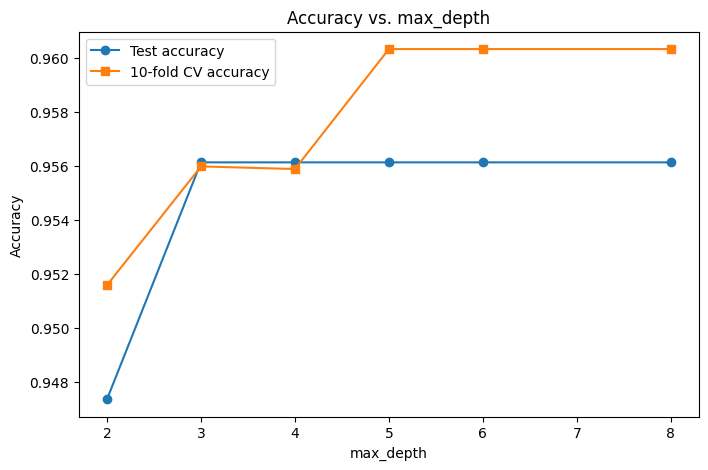

   max_depth  test_accuracy  cv_accuracy
0          2       0.947368     0.951594
1          3       0.956140     0.955990
2          4       0.956140     0.955894
3          5       0.956140     0.960338
4          6       0.956140     0.960338
5          8       0.956140     0.960338


In [14]:
def xgb_tuning_experiment(X_train, X_test, y_train, y_test, param_name, param_values, cv=10):
    """Sweep one XGBClassifier hyperparameter and track test vs. CV accuracy."""
    n_folds = min(cv, np.bincount(y_train).min())
    results = []

    for value in param_values:
        model = XGBClassifier(**{param_name: value})
        model.fit(X_train, y_train)

        test_acc = accuracy_score(y_test, model.predict(X_test))
        cv_acc = cross_val_score(model, X_train, y_train, cv=n_folds, scoring="accuracy").mean()

        results.append({param_name: value, "test_accuracy": test_acc, "cv_accuracy": cv_acc})

    results_df = pd.DataFrame(results)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(results_df[param_name], results_df["test_accuracy"], marker="o", label="Test accuracy")
    ax.plot(results_df[param_name], results_df["cv_accuracy"], marker="s", label=f"{n_folds}-fold CV accuracy")
    ax.set_xlabel(param_name)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Accuracy vs. {param_name}")
    ax.legend()
    plt.show()

    return results_df


n_estimators_tuning = xgb_tuning_experiment(X_train, X_test, y_train, y_test, "n_estimators", [10, 50, 100, 200, 500])
print(n_estimators_tuning)
# Recommendation: pick the smallest n_estimators where CV accuracy plateaus, since larger
# values add compute without improving accuracy on this tiny dataset.

max_depth_tuning = xgb_tuning_experiment(X_train, X_test, y_train, y_test, "max_depth", [2, 3, 4, 5, 6, 8])
print(max_depth_tuning)
# Recommendation: pick the smallest max_depth where CV accuracy peaks, since deeper trees
# risk overfitting the 8-row training set without a meaningful accuracy gain.
